# LLaMA Factory를 이용한 QLoRA 파인튜닝 실습

**LLaMA Factory** 프레임워크를 사용하여 대규모 언어 모델(LLM)을 **QLoRA** 기법으로 파인튜닝하는 방법을 학습합니다.

### 참고 자료
- [LLaMA Factory 공식 문서](https://llamafactory.readthedocs.io/en/latest/)
- [SK Devocean - No-Code LLM 파인튜닝](https://devocean.sk.com/blog/techBoardDetail.do?ID=166098)
- [LLaMA Factory GitHub](https://github.com/hiyouga/LLaMA-Factory)


## LLaMA Factory란?

**LLaMA Factory** 는 코드 작성 없이도 다양한 LLM을 효율적으로 파인튜닝할 수 있는 통합 프레임워크입니다.

### 주요 특징

#### No-Code 지원
- **Web UI (Gradio)**: 코드 없이 브라우저에서 모델 학습
- **CLI**: 명령줄 인터페이스로 간편한 실행  
- **Python API**: 프로그래밍 방식의 세밀한 제어

#### 다양한 모델 지원
- LLaMA, Mistral, Qwen, Gemma 등 100+ 모델
- Hugging Face Hub와 완벽 통합

#### 효율적인 학습 기법
- **QLoRA**: 양자화 + LoRA (4-bit)
- **LoRA**: Low-Rank Adaptation
- **Full Fine-tuning**: 전체 파라미터 학습

#### 고급 기능
- RLHF, DPO, PPO 지원
- 멀티 GPU 학습
- 다양한 형식으로 내보내기 (GGUF, AWQ, GPTQ)

### LLaMA Factory의 장점

| 장점 | 설명 |
|------|------|
| **빠른 시작** | 복잡한 코드 없이 즉시 시작 |
| **비용 효율** | QLoRA로 적은 GPU 메모리로 학습 |
| **사용 편의성** | Web UI로 직관적인 설정 |
| **유연성** | CLI, API, UI 모두 지원 |
| **통합 관리** | 데이터-학습-평가-배포 원스톱 |


## QLoRA (Quantized Low-Rank Adaptation)

**QLoRA** 는 4-bit 양자화와 LoRA를 결합하여 메모리 효율적으로 대규모 모델을 파인튜닝하는 기법입니다.


### 메모리 비교

> 전통적 Fine-tuning vs QLoRA (7B 모델 기준)

- Full Fine-tuning:     ~28GB GPU 메모리 필요
- LoRA (16-bit):        ~14GB GPU 메모리 필요  
- QLoRA (4-bit):        ~6GB GPU 메모리 필요


### 주요 하이퍼파라미터

| 파라미터 | 설명 | 권장값 |
|---------|------|--------|
| `lora_rank` | LoRA 어댑터 크기 | 8, 16, 32 |
| `lora_alpha` | 스케일링 팩터 | 16, 32, 64 |
| `lora_dropout` | 드롭아웃 비율 | 0.05, 0.1 |
| `lora_target` | 적용할 레이어 | all, q_proj,v_proj |


### 하이퍼파라미터 가이드

| 파라미터 | 작은 값 | 큰 값 | 권장 |
|---------|--------|-------|------|
| lora_rank | 메모리↓ | 성능↑ | 8-32 |
| batch_size | 메모리↓ | 안정↑ | 4-16 |
| learning_rate | 안정 | 빠름 | 2e-4 |
| epochs | 빠름 | 과적합↑ | 3-5 |

### 메모리 부족 시

```bash
# 1. 배치 크기 줄이기
--per_device_train_batch_size 1

# 2. LoRA 랭크 줄이기
--lora_rank 8

# 3. 시퀀스 길이 줄이기
--cutoff_len 256

# 4. 더 작은 모델 사용
--model_name_or_path Qwen/Qwen2.5-0.5B-Instruct
```

# 예제 

## 데이터셋 준비

### 데이터 로드 및 확인

의료 상담 데이터셋(illnesses.csv)을 LLaMA Factory가 인식할 수 있는 형식으로 변환합니다.

In [1]:
import pandas as pd

# 데이터 로드
df = pd.read_csv("data/illnesses.csv")
print(f"총 {len(df)}개 샘플")
print(f"\n샘플 미리보기:")
print(df[['user_input', 'reference']].head(2))

총 793개 샘플

샘플 미리보기:
                                       user_input  \
0      소아청소년과에서 수족구병에 대해 부모님들이 알아야 할 중요한 정보는 뭐에요?   
1  일본뇌염 예방을 위해 IR3535 성분의 모기기피제를 사용하는 것이 왜 중요한가요?   

                                           reference  
0  수족구병은 전염성이 매우 강한 질병으로, 급성기에는 어린이집이나 유치원에 보내지 않...  
1  IR3535 성분의 모기기피제를 사용하는 것은 일본뇌염 경보가 발령된 상황에서 모기...  


### 학습/검증 분할

In [2]:
from sklearn.model_selection import train_test_split

# 학습/검증 분할
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"\n학습: {len(train_df)}, 검증: {len(val_df)}")



학습: 713, 검증: 80


### Alpaca 형식으로 변환 및 저장

In [3]:
# Alpaca 형식으로 변환
def to_alpaca(dataframe):
    data = []
    for _, row in dataframe.iterrows():
        data.append({
            "instruction": "당신은 소아청소년과 전문의입니다. 다음 질문에 답변해주세요.",
            "input": row['user_input'],
            "output": row['reference']
        })
    return data
    

In [4]:
train_data = to_alpaca(train_df)
val_data = to_alpaca(val_df)


> 데이터 저장

In [5]:
import json
from pathlib import Path

# 저장
Path("data").mkdir(exist_ok=True)
with open("data/medical_train.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)
with open("data/medical_val.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

print(f"데이터 저장 완료")
print(f"   data/medical_train.json ({len(train_data)} 샘플)")
print(f"   data/medical_val.json ({len(val_data)} 샘플)")


데이터 저장 완료
   data/medical_train.json (713 샘플)
   data/medical_val.json (80 샘플)


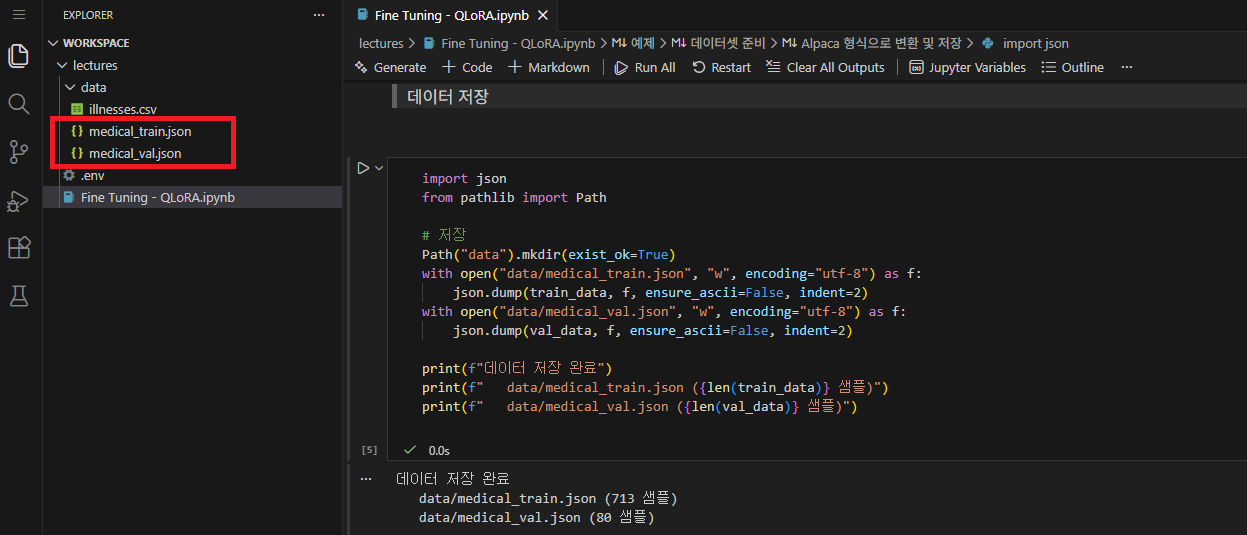

> dataset_info.json 생성

In [6]:
# dataset_info.json 생성
dataset_info = {
    "medical_train": {
        "file_name": "medical_train.json",
        "formatting": "alpaca"
    },
    "medical_val": {
        "file_name": "medical_val.json",
        "formatting": "alpaca"
    }
}

with open("data/dataset_info.json", "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print("dataset_info.json 생성 완료")
print(json.dumps(dataset_info, ensure_ascii=False, indent=2))


dataset_info.json 생성 완료
{
  "medical_train": {
    "file_name": "medical_train.json",
    "formatting": "alpaca"
  },
  "medical_val": {
    "file_name": "medical_val.json",
    "formatting": "alpaca"
  }
}


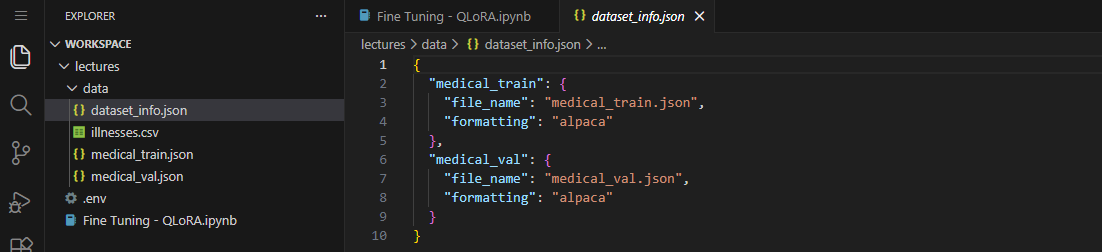

## 예제: LLaMA Factory Python API


In [10]:
from dotenv import load_dotenv

# .env 파일에 기록된 환경 변수를 시스템으로 불러옵니다.
load_dotenv() 

True

In [11]:
import sys
from tqdm import tqdm as std_tqdm

# 주피터 위젯 버전의 tqdm을 일반 텍스트 버전으로 덮어씌웁니다.
import tqdm.notebook as tqdm_notebook
tqdm_notebook.tqdm = std_tqdm

In [9]:
# LLaMA Factory 및 환경 확인
try:
    import llamafactory
    print(f"LLaMA Factory: {llamafactory.__version__}")
    
    import torch
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA Available: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f}GB")
    
    print("\n모든 패키지가 정상 설치되었습니다!")
except Exception as e:
    print(f"오류: {e}")


LLaMA Factory: 0.9.1
PyTorch: 2.4.0+cu121
CUDA Available: True
GPU: NVIDIA RTX A5000
GPU Memory: 23.6GB

모든 패키지가 정상 설치되었습니다!


### QLoRA 학습 실행

In [21]:
args = dict(
    # --- 기본 학습 및 실행 설정 ---
    stage="sft",
    do_train=True,
    do_eval=True,
    model_name_or_path="Qwen/Qwen2.5-1.5B-Instruct",
    
    # --- 데이터셋 설정 ---
    dataset="medical_train",
    eval_dataset="medical_val",
    dataset_dir="data",
    template="qwen",
    
    # --- LoRA 설정 ---
    finetuning_type="lora",
    lora_target="all",
    
    # --- WandB 로깅 설정 (추가된 부분) ---
    report_to="wandb",                  # 중요: 학습 로그를 어디로 보낼지 설정 ("wandb" 또는 "all")
    run_name="qwen2.5_medical_run_v1",  # WandB 대시보드에 표시될 개별 실험(Run) 이름
    
    # --- 학습 기간 정의 ---
    num_train_epochs=10.0,
    max_steps=1000,                     # 1000스텝에 도달하면 10에폭 전이라도 종료
    
    # --- 평가 및 저장 전략 ---
    eval_strategy="steps",
    eval_steps=50,                      # 50스텝마다 평가 결과가 WandB에 기록됨
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    
    # --- 출력 및 하이퍼파라미터 ---
    output_dir="outputs/medical_qwen_python",
    overwrite_output_dir=True,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    
    # --- 최적화 설정 ---
    fp16=True,
    quantization_bit=4,
    logging_steps=10,                   # 10스텝마다 Loss 곡선이 WandB에 업데이트됨
)

In [22]:
from transformers import EarlyStoppingCallback # 콜백 임포트

# patience=3: 3번의 eval_steps(총 300스텝) 동안 개선 안 되면 중단
# threshold=0.001: 개선되었다고 볼 최소 수치
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3, 
    early_stopping_threshold=0.001
)

In [26]:
from llamafactory.train.tuner import run_exp

run_exp(args, callbacks=[early_stopping])

[INFO|training_args.py:2147] 2026-01-07 07:10:00,951 >> PyTorch: setting up devices


[WARNING|2026-01-07 07:10:00] llamafactory.hparams.parser:162 >> We recommend enable `upcast_layernorm` in quantized training.
[INFO|2026-01-07 07:10:00] llamafactory.hparams.parser:355 >> Process rank: 0, device: cuda:0, n_gpu: 1, distributed training: False, compute dtype: torch.float16


[INFO|configuration_utils.py:679] 2026-01-07 07:10:01,038 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:10:01,042 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": null,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.46.1",
  "use_cache": tr

[INFO|tokenization_utils_base.py:2475] 2026-01-07 07:10:01,462 >> Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
[INFO|configuration_utils.py:679] 2026-01-07 07:10:01,607 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:10:01,609 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rop

[INFO|2026-01-07 07:10:02] llamafactory.data.template:157 >> Replace eos token: <|im_end|>
[INFO|2026-01-07 07:10:02] llamafactory.data.loader:157 >> Loading dataset medical_train.json...
[INFO|2026-01-07 07:10:02] llamafactory.data.loader:157 >> Loading dataset medical_val.json...
training example:
input_ids:
[151644, 8948, 198, 2610, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 64795, 82528, 33704, 126291, 52959, 143413, 53680, 56419, 51588, 20401, 78952, 13, 126844, 138520, 19391, 143604, 33883, 91669, 624, 52959, 20487, 126327, 89860, 135508, 63089, 74361, 230, 40853, 12802, 133396, 125580, 17877, 53618, 85403, 129439, 19969, 137676, 89659, 95002, 18585, 238, 33704, 132779, 31328, 19969, 35711, 30, 151645, 198, 151644, 77091, 198, 52959, 20487, 126253, 32129, 125166, 88259, 83036, 3315, 103, 121, 19391, 137601, 12802, 47818, 20487, 34395, 125206, 128844, 46682, 12802, 32129, 50340, 130974, 49052, 11, 23084, 16560, 89860, 135508, 63089, 74361, 230, 40853, 32077, 28733,

...

Step,Training Loss,Validation Loss
50,1.861600,1.729952
100,1.249200,1.452349
150,0.799400,1.282677
200,0.543000,1.188186
250,0.397000,1.173909
300,0.274300,1.200399
350,0.185200,1.224101
400,0.132900,1.266347


[INFO|trainer.py:4117] 2026-01-07 07:11:30,933 >> 
***** Running Evaluation *****
[INFO|trainer.py:4119] 2026-01-07 07:11:30,934 >>   Num examples = 80
[INFO|trainer.py:4122] 2026-01-07 07:11:30,935 >>   Batch size = 8
[INFO|trainer.py:3801] 2026-01-07 07:11:32,918 >> Saving model checkpoint to outputs/medical_qwen_python/checkpoint-50
[INFO|configuration_utils.py:679] 2026-01-07 07:11:33,029 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:11:33,031 >> Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_att

***** train metrics *****
  epoch                    =     9.0391
  total_flos               = 12469674GF
  train_loss               =     0.7935
  train_runtime            = 0:10:41.63
  train_samples_per_second =     24.936
  train_steps_per_second   =      1.559


[INFO|modelcard.py:449] 2026-01-07 07:20:55,975 >> Dropping the following result as it does not have all the necessary fields:
{'task': {'name': 'Causal Language Modeling', 'type': 'text-generation'}}


***** eval metrics *****
  epoch                   =     9.0391
  eval_loss               =     1.1739
  eval_runtime            = 0:00:02.01
  eval_samples_per_second =     39.756
  eval_steps_per_second   =       4.97


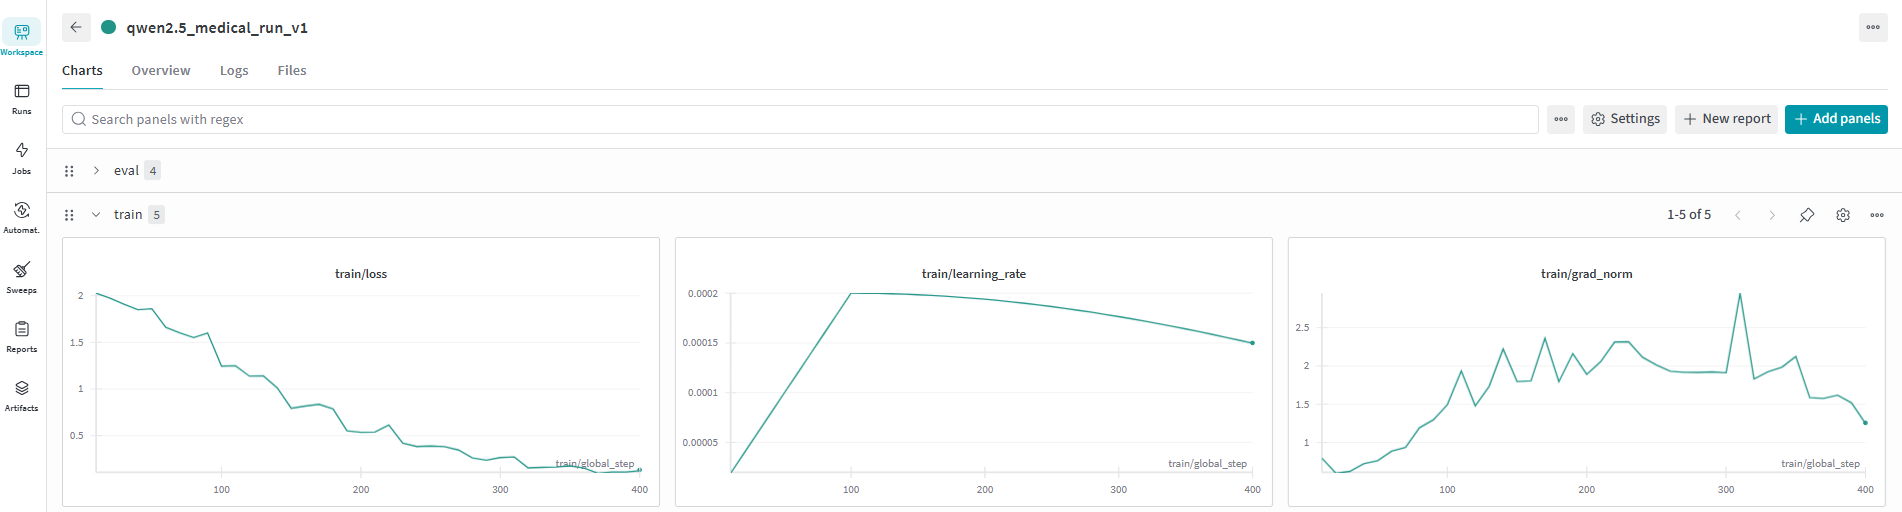

### 추론

In [4]:
from llamafactory.chat import ChatModel

def inference(msg:str):
    args = dict(
        model_name_or_path="Qwen/Qwen2.5-1.5B-Instruct",
        # 이전 코드: "outputs/medical_qwen_qlora" -> 오류 발생!
        # 수정 코드: 실제 폴더가 존재하는 경로로 변경
        adapter_name_or_path="outputs/medical_qwen_python", 
        template="qwen",
        finetuning_type="lora",
        quantization_bit=4,
    )
    chat_model = ChatModel(args)

    messages = [{"role": "user", "content": msg}]
    responses = chat_model.chat(messages)
    
    for response in responses:
        print(f"모델 답변: {response.response_text}")

In [5]:
inference("복통이 심할 때 어떻게 해야 하나요?")

[INFO|configuration_utils.py:679] 2026-01-07 07:28:59,125 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:28:59,129 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": null,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.46.1",
  "use_cache": tr

[INFO|tokenization_utils_base.py:2475] 2026-01-07 07:28:59,511 >> Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
[INFO|configuration_utils.py:679] 2026-01-07 07:28:59,655 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:28:59,658 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rop

[INFO|2026-01-07 07:29:00] llamafactory.data.template:157 >> Replace eos token: <|im_end|>


[INFO|configuration_utils.py:679] 2026-01-07 07:29:00,109 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:29:00,111 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21,
  "model_type": "qwen2",
  "num_attention_heads": 12,
  "num_hidden_layers": 28,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": null,
  "tie_word_embeddings": true,
  "torch_dtype": "bfloat16",
  "transformers_version": "4.46.1",
  "use_cache": tr

[INFO|2026-01-07 07:29:00] llamafactory.model.model_utils.quantization:157 >> Quantizing model to 4 bit with bitsandbytes.
[INFO|2026-01-07 07:29:00] llamafactory.model.patcher:157 >> Using KV cache for faster generation.


[INFO|modeling_utils.py:3937] 2026-01-07 07:29:00,136 >> loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/model.safetensors
[INFO|modeling_utils.py:1670] 2026-01-07 07:29:00,150 >> Instantiating Qwen2ForCausalLM model under default dtype torch.bfloat16.
[INFO|configuration_utils.py:1096] 2026-01-07 07:29:00,153 >> Generate config GenerationConfig {
  "bos_token_id": 151643,
  "eos_token_id": 151645
}

[INFO|modeling_utils.py:4800] 2026-01-07 07:29:01,221 >> All model checkpoint weights were used when initializing Qwen2ForCausalLM.

[INFO|modeling_utils.py:4808] 2026-01-07 07:29:01,223 >> All the weights of Qwen2ForCausalLM were initialized from the model checkpoint at Qwen/Qwen2.5-1.5B-Instruct.
If your task is similar to the task the model of the checkpoint was trained on, you can already use Qwen2ForCausalLM for predictions without further training.
[INFO|configurat

[INFO|2026-01-07 07:29:01] llamafactory.model.model_utils.attention:157 >> Using torch SDPA for faster training and inference.
[INFO|2026-01-07 07:29:03] llamafactory.model.adapter:157 >> Loaded adapter(s): outputs/medical_qwen_python
[INFO|2026-01-07 07:29:03] llamafactory.model.loader:157 >> all params: 1,552,946,688
모델 답변: 복통이 심할 경우, 응급실을 방문하거나 병원에서 진료를 받는 것이 좋습니다. 복통이 1시간 이상 지속되거나 점점 더 심해지거나, 함께 나타나거나, 배를 만지면 지나치게 아프거나, 기운이 없고 탈경련을 보이는 경우에는 즉시 응급실에 가야 합니다.


## 예제: LLaMA Factory CLI


In [6]:
!llamafactory-cli version


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/usr/local/lib/python3.11/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
----------------------------------------------------------
| Welcome to LLaMA Factory, version 0.9.1                |
|                                                        |
| Project page: https://github.com/hiyouga/LLaMA-Factory |
----------------------------------------------------------


### 주요 명령어 모음

```bash
# 학습
llamafactory-cli train [옵션]

# 추론/대화
llamafactory-cli chat [옵션]

# Web UI
llamafactory-cli webui

# 모델 내보내기
llamafactory-cli export [옵션]

# 평가
llamafactory-cli eval [옵션]

# 버전 확인
llamafactory-cli version
```

### 학습 명령어

**기본 형식:**
```bash
llamafactory-cli train \
    --model_name_or_path MODEL \
    --dataset DATASET \
    --output_dir OUTPUT \
    [옵션...]
```

### QLoRA 학습 실행


> LLaMA Factory CLI로 QLoRA 학습 실행   
> 아래 명령어를 터미널에서 실행하세요

```shell
!llamafactory-cli train \
    --stage sft \                                       # 학습 단계 설정 (Supervised Fine-Tuning)
    --do_train true \                                   # 학습 실행 여부 설정
    --load_best_model_at_end true \                     # 학습 종료 후 가장 결과(Loss 등)가 좋았던 체크포인트를 최종 모델로 로드
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \   # 베이스가 되는 사전 학습된 모델 경로
    --dataset medical_train \                           # dataset_info.json에 등록된 학습용 데이터셋 별칭
    --dataset_dir data \                                # 데이터셋 설정 파일과 데이터가 들어있는 폴더
    --template qwen \                                   # Qwen 모델의 대화 양식(Template) 적용
    --finetuning_type lora \                            # LoRA(Low-Rank Adaptation) 미세조정 방식 사용
    --lora_target all \                                 # 모델의 모든 선형 레이어에 LoRA 적용
    --output_dir outputs/medical_qwen_qlora \           # 학습된 모델과 체크포인트가 저장될 경로
    --overwrite_output_dir true \                       # 결과 폴더가 이미 있으면 덮어쓰기
    --eval_strategy steps \                             # 평가 수행 방식 (일정 스텝마다 평가)
    --save_strategy steps \                             # 저장 수행 방식 (일정 스텝마다 저장)
    --eval_steps 100 \                                  # 100스텝마다 평가 수행 (load_best_model_at_end를 위해 필수)
    --save_steps 100 \                                  # 100스텝마다 체크포인트 저장 (eval_steps와 일치 권장)
    --num_train_epochs 3 \                              # 전체 데이터를 총 3번 반복하여 학습
    --per_device_train_batch_size 4 \                   # 그래픽카드(GPU) 1개당 한 번에 학습할 데이터 개수
    --gradient_accumulation_steps 4 \                   # 가중치 업데이트 전 4번의 스텝을 누적 (실제 배치 사이즈 = 4 * 4 = 16 효과)
    --learning_rate 2e-4 \                              # 모델이 가중치를 조정하는 속도(학습률)
    --lr_scheduler_type cosine \                        # 학습률을 코사인 곡선 형태로 서서히 감소시킴
    --warmup_ratio 0.1 \                                # 초기 학습 안정화를 위해 학습률을 서서히 올리는 구간 비율
    --logging_steps 10 \                                # 10스텝마다 로그(현재 Loss 등)를 화면에 출력
    --val_size 0.1 \                                    # 전체 학습 데이터 중 10%를 검증(Validation)용으로 자동 분리
    --quantization_bit 4 \                              # 4비트 양자화(QLoRA)를 사용하여 비디오 메모리(VRAM) 절약
    --fp16 true                                         # 16비트 부동소수점 연산으로 학습 속도 향상
```

In [13]:
!llamafactory-cli train \
    --stage sft \
    --do_train true \
    --do_eval true \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --dataset medical_train \
    --eval_dataset medical_val \
    --dataset_dir data \
    --template qwen \
    --finetuning_type lora \
    --lora_target all \
    --report_to wandb \
    --run_name qwen2.5_medical_run_v1 \
    --output_dir outputs/medical_qwen_cli \
    --overwrite_output_dir true \
    --num_train_epochs 10.0 \
    --max_steps 500 \
    --eval_strategy steps \
    --eval_steps 50 \
    --save_strategy steps \
    --save_steps 50 \
    --load_best_model_at_end true \
    --metric_for_best_model loss \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 4 \
    --learning_rate 2e-4 \
    --lr_scheduler_type cosine \
    --warmup_ratio 0.1 \
    --logging_steps 10 \
    --quantization_bit 4 \
    --fp16 true

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/usr/local/lib/python3.11/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[WARNING|2026-01-07 07:46:40] llamafactory.hparams.parser:162 >> We recommend enable `upcast_layernorm` in quantized training.
[INFO|2026-01-07 07:46:40] llamafactory.hparams.parser:355 >> Process rank: 0, device: cuda:0, n_gpu: 1, distributed training: False, compute dtype: torch.float16
[INFO|configuration_utils.py:679] 2026-01-07 07:46:40,894 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 07:46:40,895 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "ar

### 추론


```shell
llamafactory-cli chat \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --adapter_name_or_path outputs/medical_qwen_cli \
    --template qwen \
    --finetuning_type lora \
    --quantization_bit 4
```

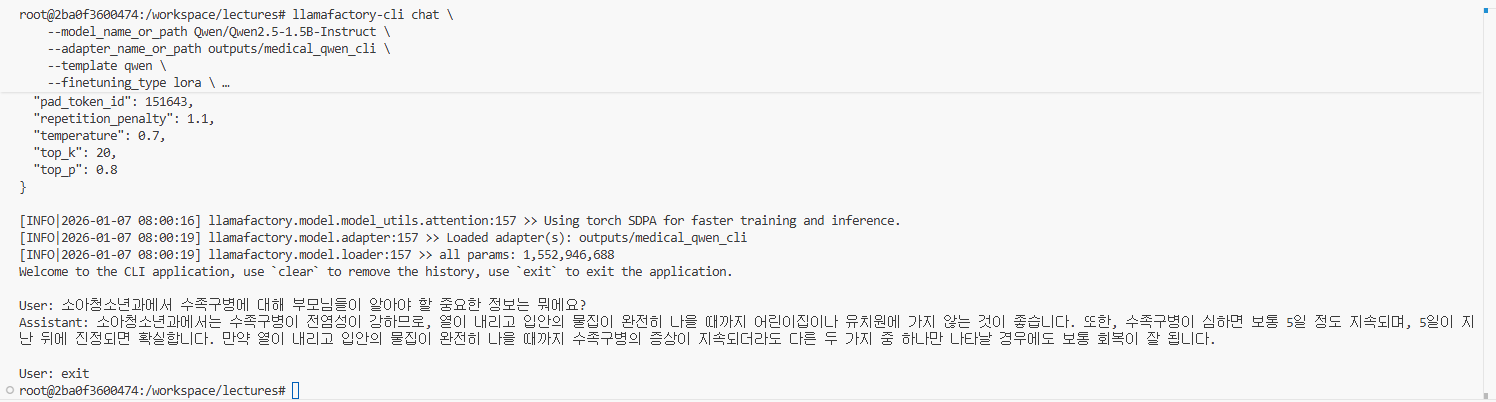

### LoRA 어댑터 병합


```shell
llamafactory-cli export \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --adapter_name_or_path outputs/medical_qwen_cli \
    --template qwen \
    --finetuning_type lora \
    --export_dir outputs/medical_qwen_merged_final \
    --export_size 2 \
    --export_device cpu \
    --export_legacy_format false
```

In [14]:
!llamafactory-cli export \
    --model_name_or_path Qwen/Qwen2.5-1.5B-Instruct \
    --adapter_name_or_path outputs/medical_qwen_cli \
    --template qwen \
    --finetuning_type lora \
    --export_dir outputs/medical_qwen_merged_final \
    --export_size 2 \
    --export_device cpu \
    --export_legacy_format false

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/usr/local/lib/python3.11/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[INFO|configuration_utils.py:679] 2026-01-07 08:02:49,131 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json
[INFO|configuration_utils.py:746] 2026-01-07 08:02:49,132 >> Model config Qwen2Config {
  "_name_or_path": "Qwen/Qwen2.5-1.5B-Instruct",
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "max_position_embeddings": 32768,
  "max_window_layers": 21

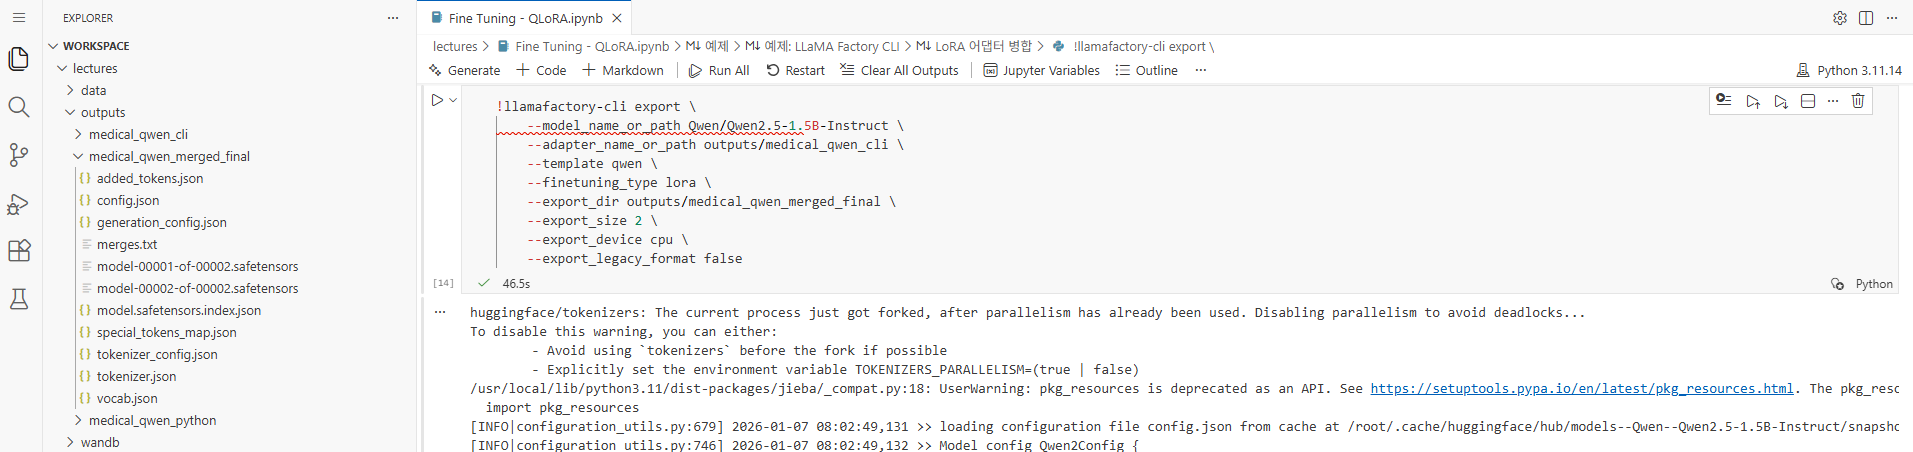

## HuggingFace 업로드

In [15]:
import os
from huggingface_hub import login

login(
    token=os.environ["HF_TOKEN"]
)
print("로그인 성공")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


로그인 성공


### 기존 레포지토리 삭제 

In [16]:
from huggingface_hub import delete_repo

# 사용자의 Hugging Face 계정 ID
huggingface_id = "good593"
save_model_nm = "llama-factory-Qwen2.5-1.5B-finetune-illnesses"
new_repo_id = f"{huggingface_id}/{save_model_nm}"
print(f"new_repo_id: {new_repo_id}")

try:
    
    # 지정된 저장소를 완전히 삭제
    delete_repo(repo_id=new_repo_id)
    print("삭제가 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("삭제할 대상이 없습니다.")

new_repo_id: good593/llama-factory-Qwen2.5-1.5B-finetune-illnesses
삭제할 대상이 없습니다.


### 수동 업로드

In [17]:
from huggingface_hub import create_repo

try:
    
    # 지정된 저장소를 생성
    create_repo(
        repo_id=new_repo_id, 
        repo_type="model",   # 모델 저장소
        private=False)
    print("생성이 완료되었습니다.")
except Exception as e:
    # 삭제할 저장소가 존재하지 않거나 권한이 없는 경우
    print("생성할 대상이 없습니다.")

생성이 완료되었습니다.


In [18]:
from huggingface_hub import upload_folder

# 로컬 폴더 전체를 Hub 저장소에 업로드
print(f"new_repo_id: {new_repo_id}")

upload_folder(
    folder_path="./outputs/medical_qwen_merged_final",                    # 업로드할 로컬 폴더 경로
    path_in_repo=".",                                # 저장소 루트에 그대로 업로드
    repo_id=new_repo_id,   # 대상 저장소 (username/repo-name)
    commit_message="Upload finetuned model"
)

new_repo_id: good593/llama-factory-Qwen2.5-1.5B-finetune-illnesses


Processing Files (3 / 3): 100%|██████████| 3.10GB / 3.10GB,  143MB/s  
New Data Upload: 100%|██████████| 2.64GB / 2.64GB,  143MB/s  


CommitInfo(commit_url='https://huggingface.co/good593/llama-factory-Qwen2.5-1.5B-finetune-illnesses/commit/a310c47caa0c9d0237ca101a7a66b7a9523063a4', commit_message='Upload finetuned model', commit_description='', oid='a310c47caa0c9d0237ca101a7a66b7a9523063a4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/good593/llama-factory-Qwen2.5-1.5B-finetune-illnesses', endpoint='https://huggingface.co', repo_type='model', repo_id='good593/llama-factory-Qwen2.5-1.5B-finetune-illnesses'), pr_revision=None, pr_num=None)

### [hugging face 확인](https://huggingface.co/good593/llama-factory-Qwen2.5-1.5B-finetune-illnesses)

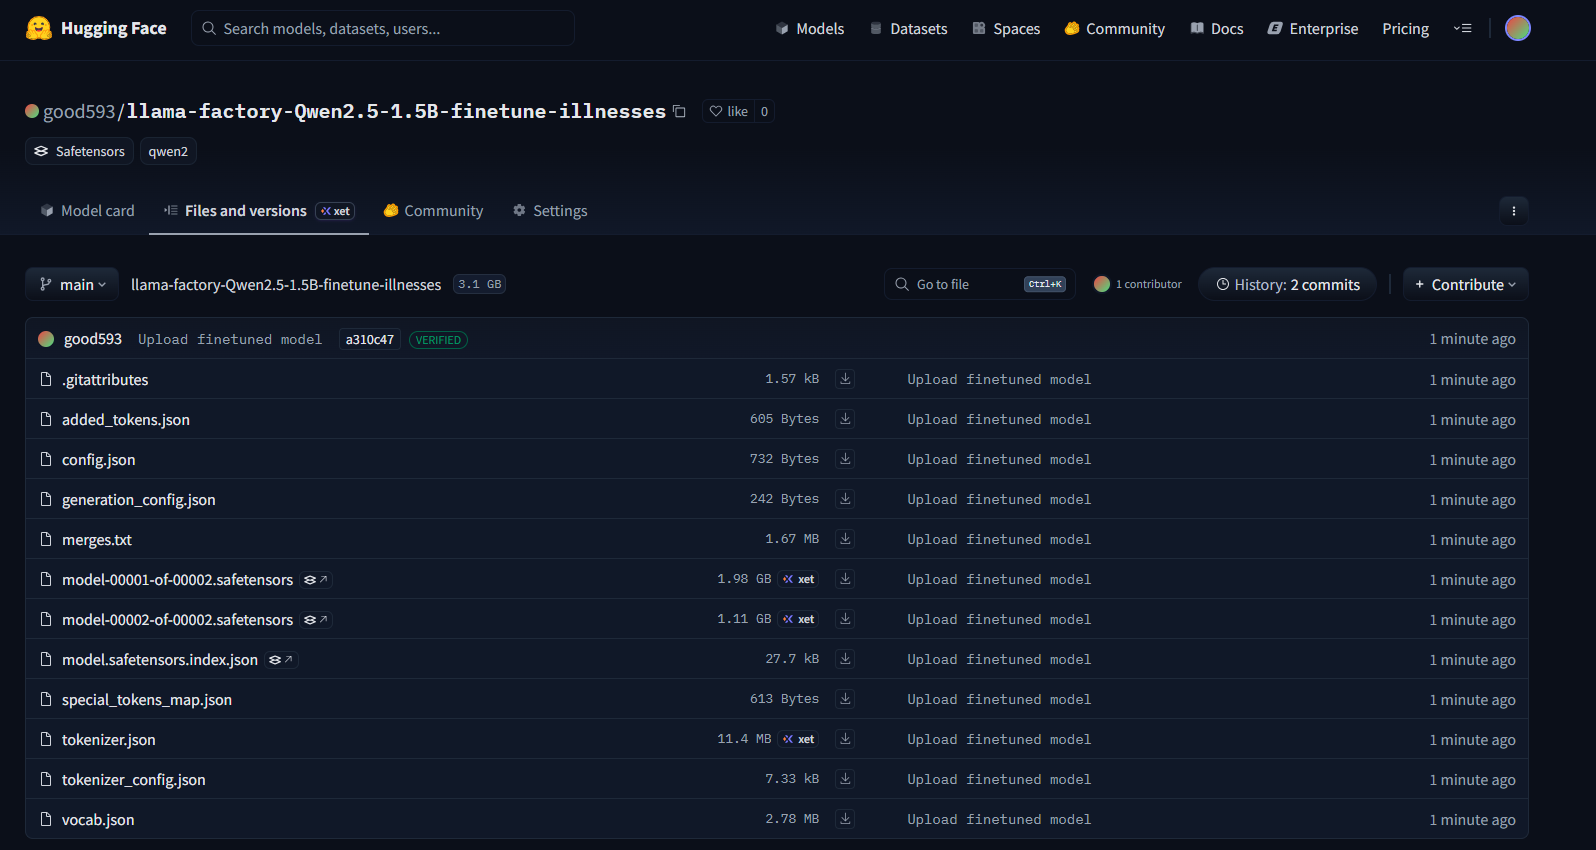